In [1]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!mkdir -p /content/drive/MyDrive/generative-models-lab

In [4]:
!ls /content/drive/MyDrive/

'Colab Notebooks'	 pptx	      SC_Project.pdf
 generative-models-lab	 Régression  'Untitled folder'


**Setup & Imports:**

In [5]:

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import numpy as np

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# Data loaders (images in [0,1])
transform = transforms.Compose([transforms.ToTensor()])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=2)

Using device: cuda


100%|██████████| 9.91M/9.91M [00:00<00:00, 16.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 487kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.58MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.75MB/s]


**AE Architecture:**

In [6]:

class Encoder(nn.Module):
    def __init__(self, latent_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, latent_dim)
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.net(x)

class Decoder(nn.Module):
    def __init__(self, latent_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 784),
            nn.Sigmoid()
        )

    def forward(self, z):
        return self.net(z).view(-1, 1, 28, 28)

class Autoencoder(nn.Module):
    def __init__(self, latent_dim: int = 16):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat

**AE Training Loop:**

In [7]:

def train_ae(model, loader, optimizer, epochs=20):
    model.train()
    losses = []
    for epoch in range(1, epochs + 1):
        epoch_loss = 0
        for x, _ in loader:
            x = x.to(DEVICE)
            optimizer.zero_grad()

            x_hat = model(x)
            loss = F.mse_loss(x_hat, x)

            loss.backward()
            optimizer.step()

            epoch_loss += loss.item() * x.size(0)

        avg = epoch_loss / len(loader.dataset)
        losses.append(avg)
        if epoch % 5 == 0:
            print(f"Epoch {epoch:3d} | Loss: {avg:.5f}")
    return losses

**AE Training Execution:**

In [8]:
# AE Training Execution
ae = Autoencoder(latent_dim=16).to(DEVICE)
ae_optimizer = optim.Adam(ae.parameters(), lr=1e-3)
ae_losses = train_ae(ae, train_loader, ae_optimizer, epochs=20)

Epoch   5 | Loss: 0.01149
Epoch  10 | Loss: 0.00903
Epoch  15 | Loss: 0.00808
Epoch  20 | Loss: 0.00753


**AE Visualization Helpers**

In [9]:
# AE Visualization Helpers
def show_reconstructions(model, loader, n=10, title="Reconstructions"):
    model.eval()
    x, _ = next(iter(loader))
    x = x[:n].to(DEVICE)
    with torch.no_grad():
        x_hat = model(x)
    comparison = torch.cat([x.cpu(), x_hat.cpu()])
    grid = make_grid(comparison, nrow=n)
    plt.figure(figsize=(15, 3))
    plt.title(title)
    plt.imshow(grid.permute(1, 2, 0).numpy(), cmap="gray")
    plt.axis("off")
    plt.show()

def plot_latent_space_2d(model, loader, device, title="2D Latent Space"):
    """Requires latent_dim=2. Re-train the AE with latent_dim=2."""
    model.eval()
    zs, labels = [], []
    with torch.no_grad():
        for x, y in loader:
            z = model.encoder(x.to(device)).cpu().numpy()
            zs.append(z)
            labels.append(y.numpy())
    zs = np.concatenate(zs)
    labels = np.concatenate(labels)
    plt.figure(figsize=(8, 6))
    sc = plt.scatter(zs[:, 0], zs[:, 1], c=labels, cmap="tab10", alpha=0.5, s=5)
    plt.colorbar(sc)
    plt.title(title)
    plt.xlabel(r"$z_1$")
    plt.ylabel(r"$z_2$")
    plt.show()

**AE Reconstruction Results:**

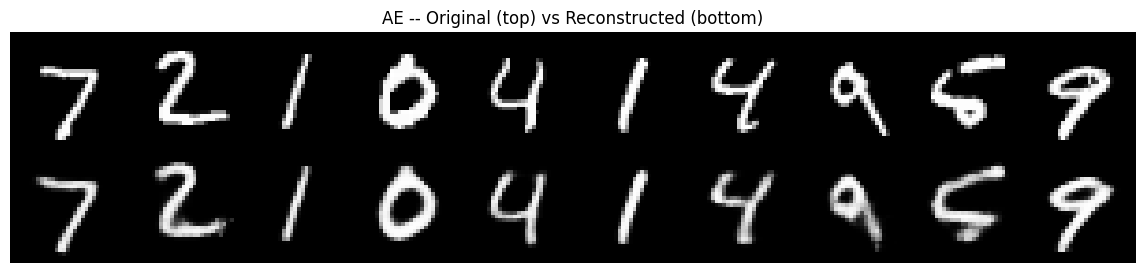

In [10]:
# AE Reconstruction Results
show_reconstructions(ae, test_loader, title="AE -- Original (top) vs Reconstructed (bottom)")

**AE 2D Latent:**

Epoch   5 | Loss: 0.04001
Epoch  10 | Loss: 0.03742
Epoch  15 | Loss: 0.03606
Epoch  20 | Loss: 0.03518


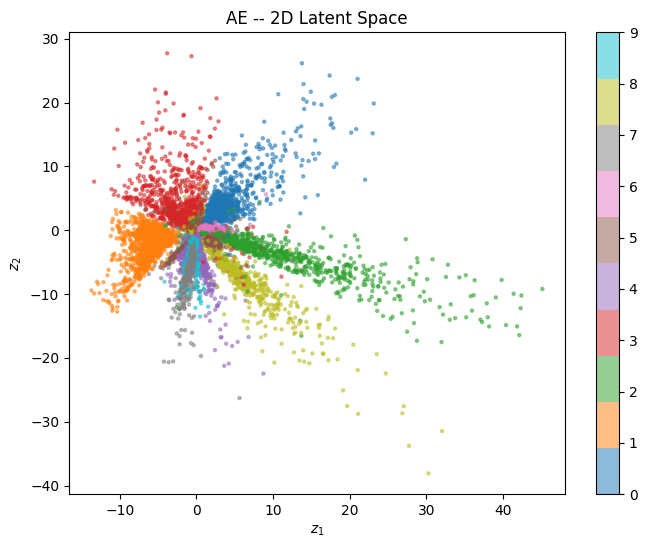

In [11]:
# AE 2D Latent Space
ae2d = Autoencoder(latent_dim=2).to(DEVICE)
opt2d = optim.Adam(ae2d.parameters(), lr=1e-3)
train_ae(ae2d, train_loader, opt2d, epochs=20)
plot_latent_space_2d(ae2d, test_loader, DEVICE, "AE -- 2D Latent Space")

**VAE Architecture:**

In [12]:
# VAE Architecture
class VAEEncoder(nn.Module):
    def __init__(self, latent_dim: int):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(784, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
        )
        self.fc_mu = nn.Linear(256, latent_dim)
        self.fc_logvar = nn.Linear(256, latent_dim)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        h = self.shared(x)
        return self.fc_mu(h), self.fc_logvar(h)

class VAEDecoder(nn.Module):
    def __init__(self, latent_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 784),
            nn.Sigmoid(),
        )

    def forward(self, z):
        return self.net(z).view(-1, 1, 28, 28)

class VAE(nn.Module):
    def __init__(self, latent_dim: int = 16):
        super().__init__()
        self.encoder = VAEEncoder(latent_dim)
        self.decoder = VAEDecoder(latent_dim)
        self.latent_dim = latent_dim

    def reparameterize(self, mu, log_var):
        if self.training:
            std = torch.exp(0.5 * log_var)
            eps = torch.randn_like(std)
            return mu + std * eps
        return mu

    def forward(self, x):
        mu, log_var = self.encoder(x)
        z = self.reparameterize(mu, log_var)
        x_hat = self.decoder(z)
        return x_hat, mu, log_var

**VAE Loss Function:**

In [13]:
# VAE Loss Function
def vae_loss(x, x_hat, mu, log_var, beta=1.0):
    # BCE reconstruction (sum over pixels, mean over batch)
    recon = F.binary_cross_entropy(x_hat, x, reduction='sum') / x.size(0)

    # KL divergence -- closed form
    kl = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp()) / x.size(0)

    return recon + beta * kl, recon, kl

**VAE Training Loop:**

In [14]:
# VAE Training Loop
def train_vae(model, loader, optimizer, epochs=20, beta=1.0):
    model.train()
    history = {"total": [], "recon": [], "kl": []}
    for epoch in range(1, epochs + 1):
        tot = rec = kl_ = 0
        for x, _ in loader:
            x = x.to(DEVICE)
            optimizer.zero_grad()

            x_hat, mu, log_var = model(x)
            loss, recon, kl = vae_loss(x, x_hat, mu, log_var, beta)

            loss.backward()
            optimizer.step()

            tot += loss.item() * x.size(0)
            rec += recon.item() * x.size(0)
            kl_ += kl.item() * x.size(0)

        n = len(loader.dataset)
        for key, val in zip(("total", "recon", "kl"), (tot, rec, kl_)):
            history[key].append(val / n)

        if epoch % 5 == 0:
            print(f"Epoch {epoch:3d} | Total: {tot/n:.3f} | Recon: {rec/n:.3f} | KL: {kl_/n:.3f}")
    return history

**VAE Training Execution**

In [15]:
# VAE Training Execution
vae = VAE(latent_dim=16).to(DEVICE)
vae_optimizer = optim.Adam(vae.parameters(), lr=1e-3)
vae_history = train_vae(vae, train_loader, vae_optimizer, epochs=20, beta=1.0)

Epoch   5 | Total: 109.043 | Recon: 90.972 | KL: 18.070
Epoch  10 | Total: 103.646 | Recon: 84.647 | KL: 19.000
Epoch  15 | Total: 101.309 | Recon: 81.986 | KL: 19.323
Epoch  20 | Total: 99.940 | Recon: 80.410 | KL: 19.530


**VAE Generation & Interpolation**

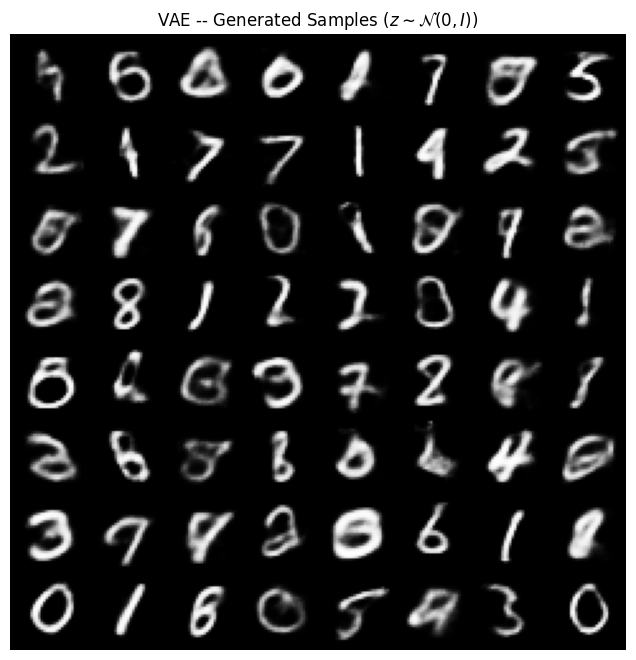

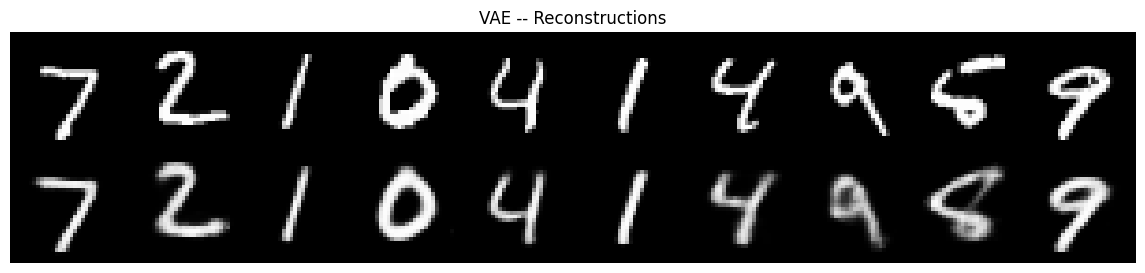

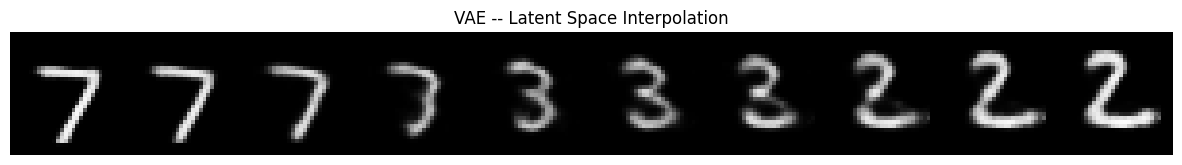

In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import numpy as np


# VAE Generation & Interpolation
def generate_samples_vae(model, n=64):
    model.eval()
    with torch.no_grad():
        z = torch.randn(n, model.latent_dim).to(DEVICE)
        samples = model.decoder(z).cpu()
    grid = make_grid(samples, nrow=8)
    plt.figure(figsize=(8, 8))
    plt.title(r"VAE -- Generated Samples ($z \sim \mathcal{N}(0,I)$)")
    plt.imshow(grid.permute(1, 2, 0).numpy(), cmap="gray")
    plt.axis("off")
    plt.show()

def interpolate_vae(model, loader, n_steps=10):
    """Linear interpolation between two latent codes."""
    model.eval()
    x, _ = next(iter(loader))
    x1, x2 = x[0:1].to(DEVICE), x[1:2].to(DEVICE)
    with torch.no_grad():
        mu1, _ = model.encoder(x1)
        mu2, _ = model.encoder(x2)
        alphas = torch.linspace(0, 1, n_steps).to(DEVICE)
        zs = torch.stack([(1-a)*mu1 + a*mu2 for a in alphas]).squeeze(1)
        imgs = model.decoder(zs).cpu()
    grid = make_grid(imgs, nrow=n_steps)
    plt.figure(figsize=(15, 2))
    plt.title("VAE -- Latent Space Interpolation")
    plt.imshow(grid.permute(1, 2, 0).numpy(), cmap="gray")
    plt.axis("off")
    plt.show()

def show_reconstructions(model, loader, n=10, title="Reconstructions"):
    model.eval()
    x, _ = next(iter(loader))
    x = x[:n].to(DEVICE)
    with torch.no_grad():
        output = model(x)
        # Check if the model returns a tuple (like VAE) or a single tensor (like AE)
        x_hat = output[0] if isinstance(output, tuple) else output
    comparison = torch.cat([x.cpu(), x_hat.cpu()])
    grid = make_grid(comparison, nrow=n)
    plt.figure(figsize=(15, 3))
    plt.title(title)
    plt.imshow(grid.permute(1, 2, 0).numpy(), cmap="gray")
    plt.axis("off")
    plt.show()

generate_samples_vae(vae)
show_reconstructions(vae, test_loader, title="VAE -- Reconstructions")
interpolate_vae(vae, test_loader)


**Beta-VAE Experiment**

Epoch   5 | Total: 151.165 | Recon: 122.162 | KL: 7.251
Epoch  10 | Total: 146.584 | Recon: 115.395 | KL: 7.797
Epoch  15 | Total: 144.458 | Recon: 112.042 | KL: 8.104
Epoch  20 | Total: 143.292 | Recon: 110.197 | KL: 8.274


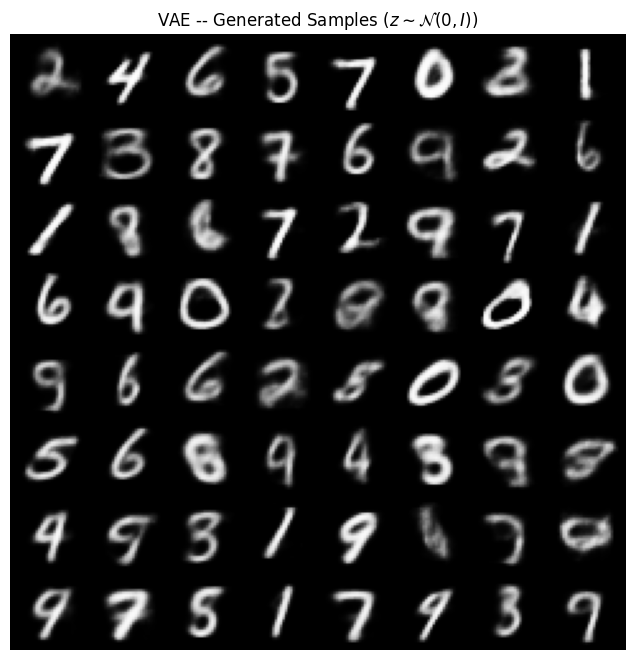

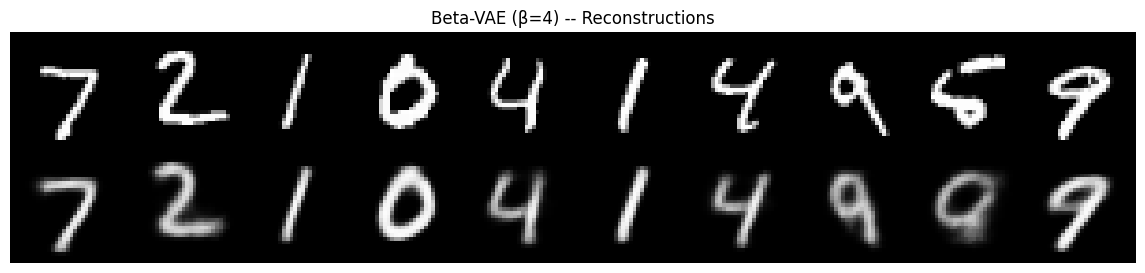

In [17]:
# Beta-VAE Experiment
beta_vae = VAE(latent_dim=16).to(DEVICE)
beta_vae_opt = optim.Adam(beta_vae.parameters(), lr=1e-3)
beta_history = train_vae(beta_vae, train_loader, beta_vae_opt, epochs=20, beta=4.0)

generate_samples_vae(beta_vae)
show_reconstructions(beta_vae, test_loader, title="Beta-VAE (β=4) -- Reconstructions")

**GAN Data Loader Setup**

In [18]:
# GAN Data Loader Setup
transform_gan = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),  # [0,1] -> [-1,1]
])
train_dataset_gan = datasets.MNIST('./data', train=True, download=True, transform=transform_gan)
train_loader_gan = DataLoader(train_dataset_gan, batch_size=128, shuffle=True, num_workers=2)

**GAN Architecture:**

In [19]:
# GAN Architecture
LATENT_DIM_GAN = 100

class Generator(nn.Module):
    def __init__(self, latent_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, 784),
            nn.Tanh()
        )

    def forward(self, z):
        return self.net(z).view(-1, 1, 28, 28)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x.view(x.size(0), -1))

**GAN Training Loop:**

In [20]:
# GAN Training Loop
def train_gan(G, D, loader, opt_G, opt_D, epochs=50):
    criterion = nn.BCELoss()
    G.train()
    D.train()
    g_losses, d_losses = [], []

    for epoch in range(1, epochs + 1):
        g_epoch = d_epoch = 0

        for real_imgs, _ in loader:
            real_imgs = real_imgs.to(DEVICE)
            bs = real_imgs.size(0)
            real_labels = torch.ones(bs, 1).to(DEVICE)
            fake_labels = torch.zeros(bs, 1).to(DEVICE)

            # Train Discriminator
            opt_D.zero_grad()
            d_loss_real = criterion(D(real_imgs), real_labels)

            z = torch.randn(bs, LATENT_DIM_GAN).to(DEVICE)
            fake_imgs = G(z).detach()
            d_loss_fake = criterion(D(fake_imgs), fake_labels)

            d_loss = 0.5 * (d_loss_real + d_loss_fake)
            d_loss.backward()
            opt_D.step()
            d_epoch += d_loss.item()

            # Train Generator
            opt_G.zero_grad()
            z = torch.randn(bs, LATENT_DIM_GAN).to(DEVICE)
            g_loss = criterion(D(G(z)), real_labels)
            g_loss.backward()
            opt_G.step()
            g_epoch += g_loss.item()

        g_losses.append(g_epoch / len(loader))
        d_losses.append(d_epoch / len(loader))

        if epoch % 10 == 0:
            print(f"Epoch {epoch:3d} | D: {d_epoch/len(loader):.4f} | G: {g_epoch/len(loader):.4f}")
            show_gan_samples(G)

    return g_losses, d_losses

def show_gan_samples(G, n=64, title="GAN -- Generated Samples"):
    G.eval()
    with torch.no_grad():
        z = torch.randn(n, LATENT_DIM_GAN).to(DEVICE)
        imgs = (G(z).cpu() + 1) / 2  # [-1,1] -> [0,1]
    grid = make_grid(imgs, nrow=8)
    plt.figure(figsize=(8, 8))
    plt.title(title)
    plt.imshow(grid.permute(1, 2, 0).numpy(), cmap="gray")
    plt.axis("off")
    plt.show()
    G.train()

**GAN Training Execution:**

Epoch  10 | D: 0.4885 | G: 1.4401


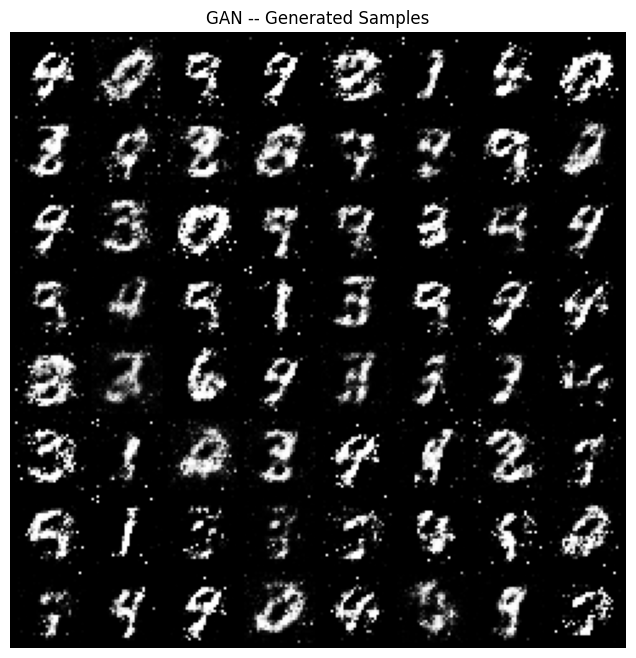

Epoch  20 | D: 0.6100 | G: 0.9754


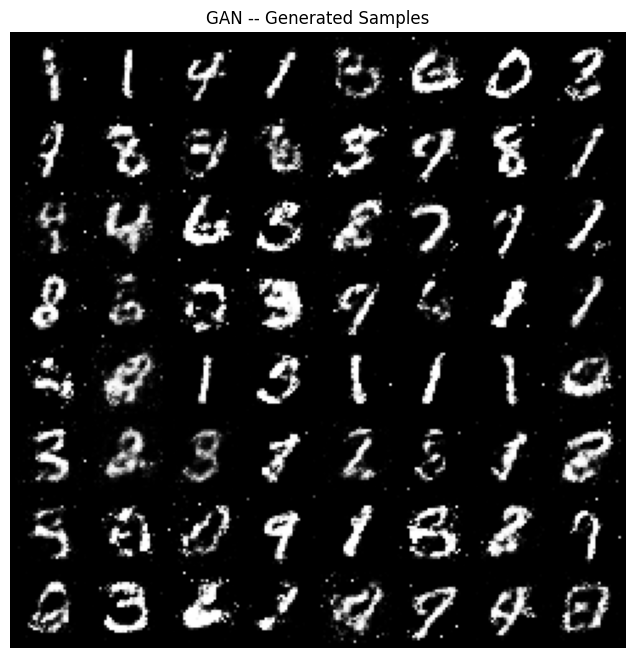

Epoch  30 | D: 0.6372 | G: 0.9098


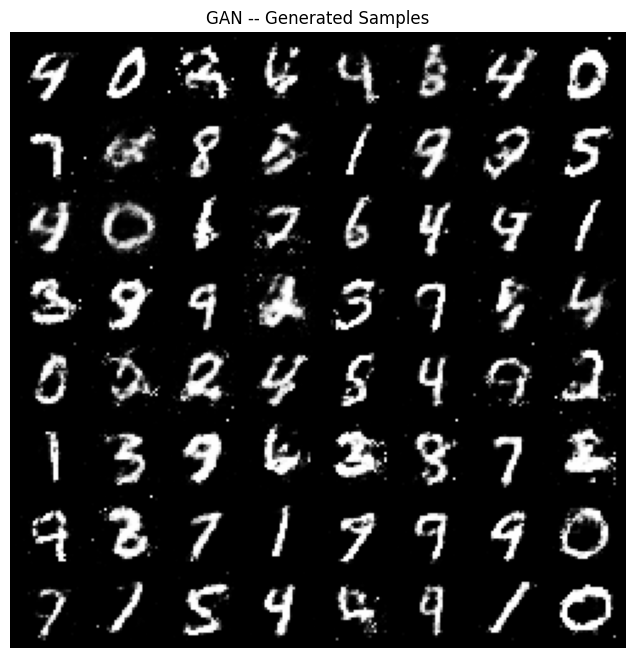

Epoch  40 | D: 0.6420 | G: 0.8818


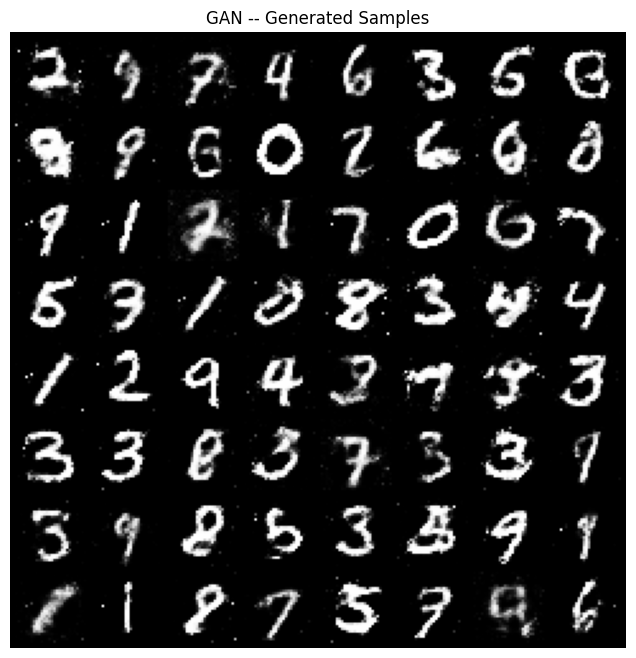

Epoch  50 | D: 0.6461 | G: 0.8685


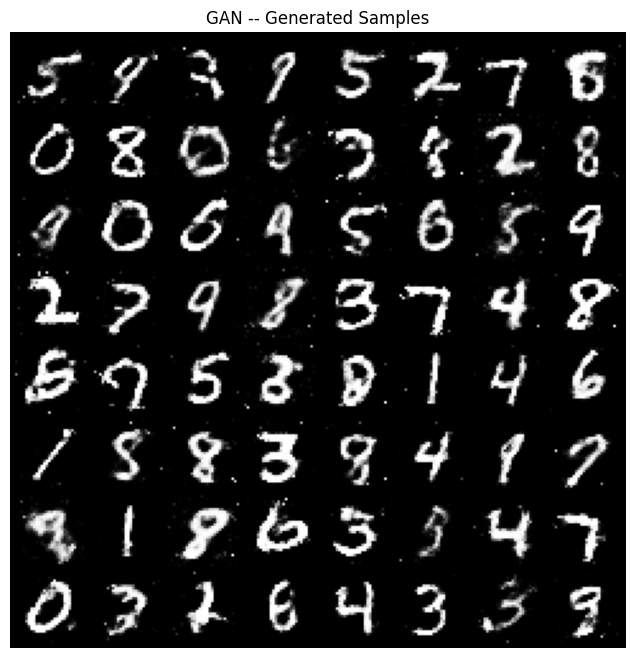

In [21]:
# GAN Training Execution
G = Generator(LATENT_DIM_GAN).to(DEVICE)
D = Discriminator().to(DEVICE)
opt_G = optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_D = optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))

g_losses, d_losses = train_gan(G, D, train_loader_gan, opt_G, opt_D, epochs=50)

**GAN Loss Curves:**

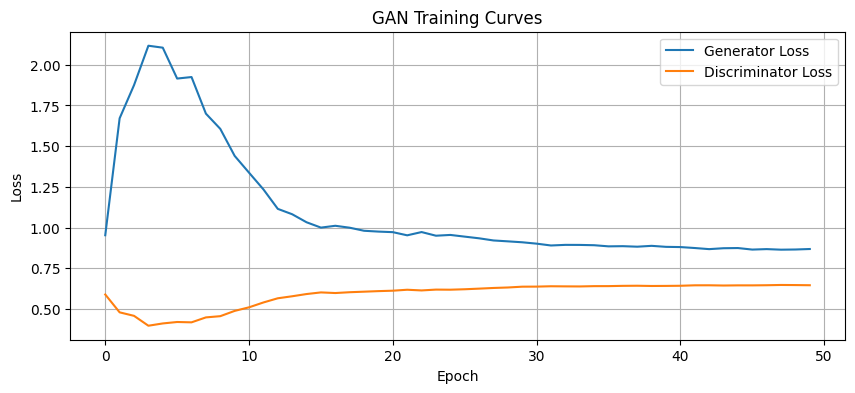

In [22]:
# GAN Loss Curves
plt.figure(figsize=(10, 4))
plt.plot(g_losses, label="Generator Loss")
plt.plot(d_losses, label="Discriminator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GAN Training Curves")
plt.legend()
plt.grid(True)
plt.show()

**Mode Collapse Experiment:**

Epoch  10 | D: 0.0000 | G: 14.8476


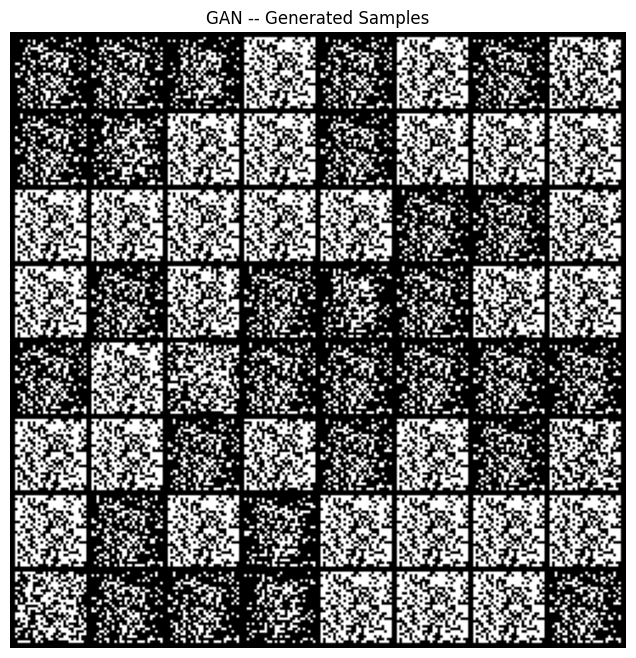

Epoch  20 | D: 0.0000 | G: 18.0838


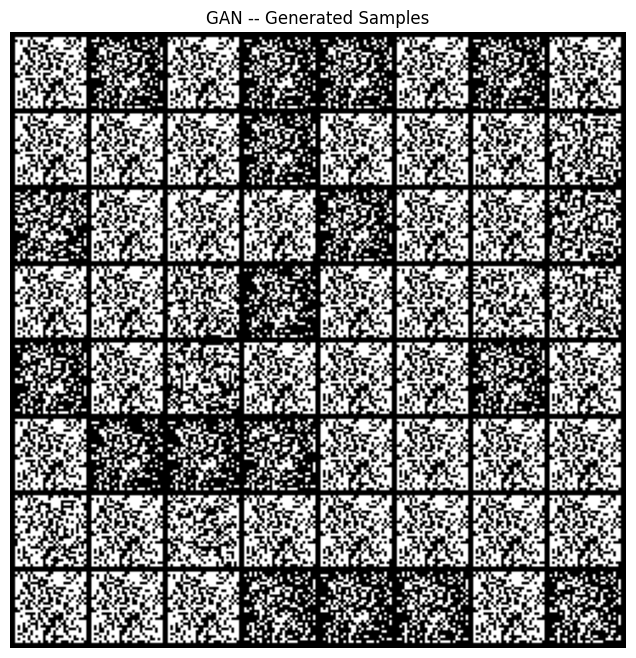

Epoch  30 | D: 0.0000 | G: 21.0214


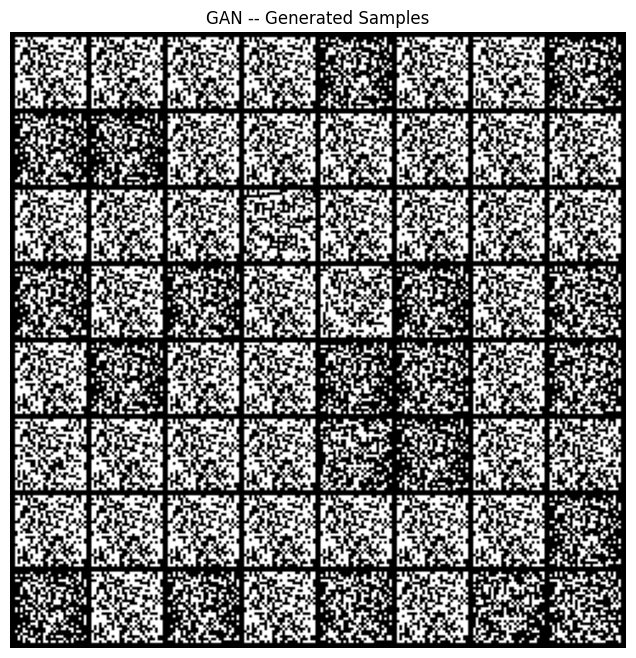

([5.4876462570639815,
  8.74866998424408,
  10.334688182578667,
  11.574630562430507,
  12.269073254518164,
  12.233670793870873,
  12.865137557739388,
  14.108844002680993,
  14.087582942011005,
  14.8476110023222,
  14.99630030080962,
  15.213654727569775,
  15.703301507018523,
  15.533456068303286,
  15.874327409496185,
  16.586938394412304,
  16.99078349619786,
  17.282743848463113,
  18.078857299869757,
  18.08379633645259,
  18.395423787489122,
  18.431575897151728,
  18.66404896961855,
  19.293064780326795,
  19.62676494411314,
  20.69613141139179,
  21.194026446799988,
  21.00259553954037,
  20.74107846827395,
  21.02144925375737],
 [0.05661083577619766,
  0.0006145395247996953,
  0.0001400108584751393,
  6.571422533846638e-05,
  3.183121624345177e-05,
  1.5907690981012668e-05,
  1.3720169427775111e-05,
  1.1478251077871802e-05,
  5.98759470740178e-06,
  6.511243826972088e-06,
  2.7681675238127045e-06,
  2.043024645122377e-06,
  1.602292742184299e-06,
  1.3165644403799699e-06,


In [23]:
# Mode Collapse Experiment
G_mc = Generator(LATENT_DIM_GAN).to(DEVICE)
D_mc = Discriminator().to(DEVICE)
opt_G_mc = optim.Adam(G_mc.parameters(), lr=1e-2, betas=(0.5, 0.999))
opt_D_mc = optim.Adam(D_mc.parameters(), lr=2e-4, betas=(0.5, 0.999))

train_gan(G_mc, D_mc, train_loader_gan, opt_G_mc, opt_D_mc, epochs=30)

**Quantitative Comparison:**

In [24]:
# Quantitative Comparison
def compute_test_mse(model, loader, model_type="ae"):
    model.eval()
    total_mse = 0
    with torch.no_grad():
        for x, _ in loader:
            x = x.to(DEVICE)
            x_hat = model(x) if model_type == "ae" else model(x)[0]
            total_mse += F.mse_loss(x_hat, x, reduction='sum').item()
    return total_mse / len(loader.dataset)

ae_mse = compute_test_mse(ae, test_loader, "ae")
vae_mse = compute_test_mse(vae, test_loader, "vae")
print(f"AE test MSE: {ae_mse:.5f}")
print(f"VAE test MSE: {vae_mse:.5f}")

AE test MSE: 6.35477
VAE test MSE: 9.11221


**Save Results to Google Drive:**

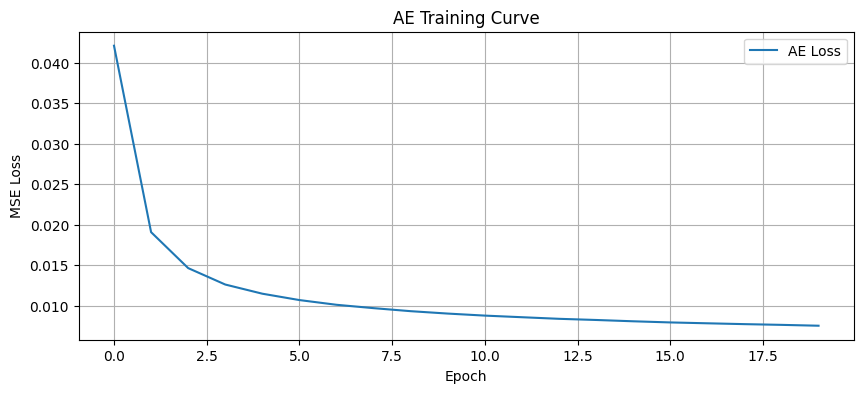

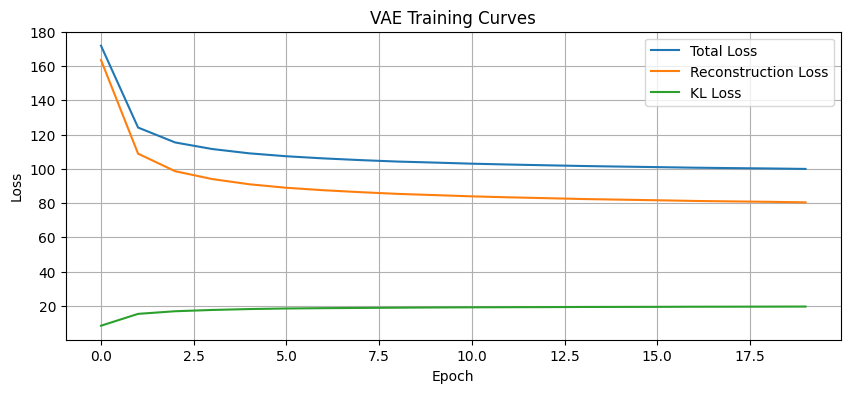

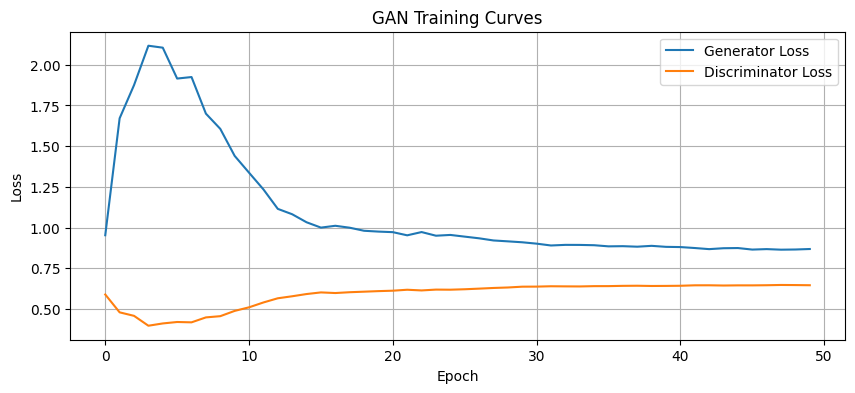

All results saved to: /content/drive/MyDrive/generative-models-lab


In [25]:
# Save Results to Google Drive
import os

save_dir = "/content/drive/MyDrive/generative-models-lab"
os.makedirs(save_dir, exist_ok=True)

# Save models
torch.save(ae.state_dict(), f"{save_dir}/ae.pth")
torch.save(vae.state_dict(), f"{save_dir}/vae.pth")
torch.save(G.state_dict(), f"{save_dir}/generator.pth")
torch.save(D.state_dict(), f"{save_dir}/discriminator.pth")

# Save loss curves
plt.figure(figsize=(10, 4))
plt.plot(ae_losses, label="AE Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("AE Training Curve")
plt.legend()
plt.grid(True)
plt.savefig(f"{save_dir}/ae_loss_curve.png")
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(vae_history["total"], label="Total Loss")
plt.plot(vae_history["recon"], label="Reconstruction Loss")
plt.plot(vae_history["kl"], label="KL Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VAE Training Curves")
plt.legend()
plt.grid(True)
plt.savefig(f"{save_dir}/vae_loss_curve.png")
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(g_losses, label="Generator Loss")
plt.plot(d_losses, label="Discriminator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GAN Training Curves")
plt.legend()
plt.grid(True)
plt.savefig(f"{save_dir}/gan_loss_curve.png")
plt.show()

print(f"All results saved to: {save_dir}")